## 1. What this notebook computes

The part of the universe we can observe is made of **matter** (protons, neutrons,
electrons); **antimatter** (antiprotons, positrons, ...) appears only for short
times, made in collisions. Why there is more matter than antimatter is an open
question of physics. In 1967 Andrei Sakharov showed that any process that makes
more matter than antimatter out of a symmetric start must meet **three
conditions**. This notebook

1. counts the conserved numbers (baryon number $B$, lepton number $L$, electric
   charge $Q$) in four processes, and shows what a violation of $B$ looks like;
2. computes, with sympy, the net baryon number made by the decays of a toy
   particle and its antiparticle: it is the product of the **violation of $B$**
   (condition 1) and of the **difference between particle and antiparticle**
   (condition 2, C and CP violation);
3. shows with the Fermi-Dirac occupations that in **thermal equilibrium** without
   a conserved $B$ particles and antiparticles are equally common, and solves a
   two-equation rate model, in closed form and with the Runge-Kutta method, in
   which an asymmetry survives only when the decays happen **out of equilibrium**
   (condition 3);
4. applies the three conditions to the theory of this book, using the verdicts of
   the Revision record: the U(1) charge is exactly conserved (condition 1 fails),
   the same-mass conjugation is an exact symmetry of the commuting field, the
   quantised field has only the mass-reversing conjugation, and no departure from
   equilibrium has been computed;
5. finds every Majorana-type mass matrix that a charge-violating term could use
   (exactly two, $C$ and $C\Gamma$; both vanish for anticommuting components);
6. draws the **scorecard**: the theory as built does not solve the
   matter-antimatter problem.

The toy computations use no measured number. Eight teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 21d (Sakharov's three conditions and the scorecard of this theory) is the file
`Revision/textbook/notebooks/21d_sakharov_scorecard.ipynb` of the repository
Dirac_claude. It teaches the three conditions that a process making more matter than
antimatter must meet (Sakharov 1967) with exact toy computations of its own: the
bookkeeping of baryon number, lepton number and electric charge in four processes; a
decay model whose net baryon number is the product of the baryon-number violation and the
particle-antiparticle difference of the decay probabilities (derived with sympy); the
Fermi-Dirac occupations of particles and antiparticles, which agree when the chemical
potential vanishes; and a two-equation rate model of decays out of equilibrium whose
final asymmetry is found in closed form and by Runge-Kutta integration. No measured
number is used. It then applies the three conditions to this theory with the verdicts of
the Revision record: the exact conservation of the U(1) charge, the same-mass conjugation
of the commuting field as an exact symmetry of the Lagrangian of the record at a point of
the author's metric, the mass-reversing conjugation of the quantised field, the two
invariant Majorana-type mass matrices C and C Gamma (charge 2, absent for anticommuting
components), and draws the scorecard: the theory as built does not solve the
matter-antimatter problem. Eight teaching plots. It needs a computer with Windows 11,
macOS or Linux, an internet connection for the installation, the program Git, and Python
3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy, sympy, mpmath and matplotlib; the other
packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 21d_sakharov_scorecard.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 20 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 21d_sakharov_scorecard.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
21d_sakharov_scorecard.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/21d.captions.json`
- `Revision/textbook/figures/21d_1_bookkeeping.png`
- `Revision/textbook/figures/21d_2_decay_asymmetry.png`
- `Revision/textbook/figures/21d_3_equilibrium_occupations.png`
- `Revision/textbook/figures/21d_4_rate_model_histories.png`
- `Revision/textbook/figures/21d_5_washout_efficiency.png`
- `Revision/textbook/figures/21d_6_lagrangian_maps.png`
- `Revision/textbook/figures/21d_7_majorana_terms.png`
- `Revision/textbook/figures/21d_8_scorecard.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the eight figure files of notebook 21d exist
    ALL 19 CHECKS PASSED (notebook 21d)

and the notebook must show 8 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/21d_sakharov_scorecard.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming a file in the folder `Revision/algebra`, `Revision/theory`,
  `Revision/pairing`, `Revision/lead_checks` or `Revision/field_equations_a4`: the
  notebook was opened outside the repository, or the repository is incomplete; clone the
  repository again and open the notebook from its folder `Revision/textbook/notebooks`.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 21d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 21d (Sakharov's three conditions and the scorecard of this theory) is the file
# Revision/textbook/notebooks/21d_sakharov_scorecard.ipynb of the repository
# Dirac_claude. It teaches the three conditions that a process making more matter than
# antimatter must meet (Sakharov 1967) with exact toy computations of its own: the
# bookkeeping of baryon number, lepton number and electric charge in four processes; a
# decay model whose net baryon number is the product of the baryon-number violation and
# the particle-antiparticle difference of the decay probabilities (derived with sympy);
# the Fermi-Dirac occupations of particles and antiparticles, which agree when the
# chemical potential vanishes; and a two-equation rate model of decays out of equilibrium
# whose final asymmetry is found in closed form and by Runge-Kutta integration. No
# measured number is used. It then applies the three conditions to this theory with the
# verdicts of the Revision record: the exact conservation of the U(1) charge, the
# same-mass conjugation of the commuting field as an exact symmetry of the Lagrangian of
# the record at a point of the author's metric, the mass-reversing conjugation of the
# quantised field, the two invariant Majorana-type mass matrices C and C Gamma (charge 2,
# absent for anticommuting components), and draws the scorecard: the theory as built does
# not solve the matter-antimatter problem. Eight teaching plots. It needs a computer with
# Windows 11, macOS or Linux, an internet connection for the installation, the program
# Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
# packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
# 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
# nbconvert 7.16.6. The notebook itself imports numpy, sympy, mpmath and matplotlib; the
# other packages run Jupyter, the program that shows and runs notebooks. It does not need
# Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 21d_sakharov_scorecard.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 20
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 21d_sakharov_scorecard.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 21d_sakharov_scorecard.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/21d.captions.json
# - Revision/textbook/figures/21d_1_bookkeeping.png
# - Revision/textbook/figures/21d_2_decay_asymmetry.png
# - Revision/textbook/figures/21d_3_equilibrium_occupations.png
# - Revision/textbook/figures/21d_4_rate_model_histories.png
# - Revision/textbook/figures/21d_5_washout_efficiency.png
# - Revision/textbook/figures/21d_6_lagrangian_maps.png
# - Revision/textbook/figures/21d_7_majorana_terms.png
# - Revision/textbook/figures/21d_8_scorecard.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the eight figure files of notebook 21d exist
#     ALL 19 CHECKS PASSED (notebook 21d)
#
# and the notebook must show 8 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/21d_sakharov_scorecard.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming a file in the folder Revision/algebra, Revision/theory,
#   Revision/pairing, Revision/lead_checks or Revision/field_equations_a4: the notebook
#   was opened outside the repository, or the repository is incomplete; clone the
#   repository again and open the notebook from its folder Revision/textbook/notebooks.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "21d"  # this notebook: chapter 21, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 21d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Quark**: a constituent of protons and neutrons. The up quark $u$ has electric
  charge $+2/3$, the down quark $d$ has $-1/3$ (in units of the proton charge);
  every quark has **baryon number** $B = 1/3$. An **antiquark** ($\bar u$, $\bar d$)
  has the opposite numbers.
- **Baryon**: a particle made of three quarks, such as the proton $p = uud$ and the
  neutron $n = udd$ ($B = 1$); a **meson** (pion $\pi$) is a quark and an antiquark
  ($B = 0$).
- **Lepton number** $L$: $+1$ for the electron $e^-$ and the neutrino $\nu_e$,
  $-1$ for the positron $e^+$ and the antineutrino $\bar\nu_e$, $0$ for quarks and
  the photon $\gamma$.
- **Conserved number**: a number whose total before a process equals its total
  after it, in every process that happens.
- **Branching probability**: the probability that a decaying particle decays in one
  particular way (one **channel**).
- **C** (charge conjugation): the exchange of particles and antiparticles; **CP**:
  C combined with a mirror reflection of space. A theory **violates** C (or CP)
  when the exchanged process does not happen with the same probability.
- **Thermal equilibrium** at temperature $T$: the state that a system reaches when
  its reactions run forwards and backwards equally often. **Fermi-Dirac
  occupation**: the probability $f(E) = 1/(e^{(E - \mu)/T} + 1)$ that a state of
  energy $E$ holds a fermion; $\mu$ is the **chemical potential** of a conserved
  number (Boltzmann's constant is 1).
- **Rate**: a number per unit time; here the time is measured in units of the
  cooling time of the toy universe.
- **U(1) charge** $Q$ of the field of this theory: the conserved number of the phase
  symmetry $\Psi \to e^{i\alpha}\Psi$, $Q = \int\cos z\,\Psi^\dagger B\Psi\,d^7x$.
- **Majorana-type term**: a term $\Psi^TM\Psi$ built from $\Psi$ twice (no
  $\Psi^\dagger$); under $\Psi \to e^{i\alpha}\Psi$ it is multiplied by
  $e^{2i\alpha}$, so it carries U(1) charge 2.
- **Status labels**: PROVED (exact), COMPUTED (numerical), ASSUMED (an input),
  HYPOTHESIS (not derived), OPEN (not answered), NOT COMPUTED (no computation
  exists).

## 4. The physical and mathematical situation

**Sakharov's three conditions** (A. D. Sakharov, 1967; quoted here as known
physics, and illustrated by the toy computations of this notebook). Suppose the
universe starts with equal amounts of matter and antimatter. To end with more
matter,

1. some process must **change the baryon number** $B$ (otherwise the total $B$,
   zero at the start, stays zero);
2. **C and CP must be violated** (otherwise every process that makes baryons has a
   mirror process that makes the same number of antibaryons at the same rate);
3. these processes must happen **out of thermal equilibrium** (in equilibrium a
   number that is not conserved has zero chemical potential, and particles and
   antiparticles are equally common).

**The theory of this book** has no quarks and no baryons. The only number of this
kind it has is the U(1) charge $Q$ of its field; the Revision record proves that
$Q$ is exactly conserved in the author's metric, for every history $a_4(x_4)$, in
particular the one in which the three extra times $x5, x6, x7$ deflate
exponentially. The notebook first teaches the three conditions on toy models and
then asks, condition by condition, what this theory does.

**Honesty.** The toy models (a decay model and a rate model) are illustrations
with ASSUMED equations; they are not part of this theory. Every statement about
this theory comes from a check of the Revision record that the notebook reads, or
from a computation of the notebook that reproduces one.

## 5. The Revision records

The next cell reads the verdicts of the Revision reports that this notebook uses:
the lead checks of charge conjugation and U(1) conservation, the pairing record,
the algebra record and the record of the Kohn-Sham source conditions. It prints
the verdicts of the checks the scorecard will rest on.

In [2]:
from fractions import Fraction  # exact fractions such as 1/3

import mpmath  # numbers with many digits and special functions
import numpy as np  # numbers, arrays, matrices
import sympy as sp  # exact algebra


def load_checks(path):
    """name -> verdict (upper case) of every check of a Revision report."""
    entries = json.loads(repository_file(path).read_text(encoding="utf-8"))["checks"]
    return {c["name"]: c["verdict"].upper() for c in entries}


LEAD_FILE = "Revision/lead_checks/reports/charge-conjugation-and-u1.json"
PAIR_FILE = "Revision/pairing/reports/wolfram-pairing.json"
ALGEBRA_FILE = "Revision/algebra/reports/python-algebra.json"
KS_FILE = "Revision/field_equations_a4/reports/ks-source-conditions.json"
LEAD, PAIR = load_checks(LEAD_FILE), load_checks(PAIR_FILE)
ALGEBRA, KS = load_checks(ALGEBRA_FILE), load_checks(KS_FILE)
USED = [(LEAD_FILE, LEAD, "u1_noether_matrix_identity"),
        (LEAD_FILE, LEAD, "representation_real"),
        (LEAD_FILE, LEAD, "spinor_connection_real"),
        (LEAD_FILE, LEAD, "bilinears_under_charge_conjugation"),
        (LEAD_FILE, LEAD, "quantum_charge_conjugation_unitary_type"),
        (PAIR_FILE, PAIR, "T1_current_primordial_commuting"),
        (PAIR_FILE, PAIR, "T1_current_primordial_grassmann"),
        (PAIR_FILE, PAIR, "T1_Lagrangian_primordial_commuting"),
        (ALGEBRA_FILE, ALGEBRA, "spin_commutant_dimension_2"),
        (KS_FILE, KS, "ks_history_is_a_prescribed_background")]
for path, verdicts, name in USED:
    say(f"record {path.split('/')[-1]}: {name} = {verdicts[name]}")

record charge-conjugation-and-u1.json: u1_noether_matrix_identity = PASS
record charge-conjugation-and-u1.json: representation_real = PASS
record charge-conjugation-and-u1.json: spinor_connection_real = PASS
record charge-conjugation-and-u1.json: bilinears_under_charge_conjugation = PASS
record charge-conjugation-and-u1.json: quantum_charge_conjugation_unitary_type = PASS
record wolfram-pairing.json: T1_current_primordial_commuting = PASS
record wolfram-pairing.json: T1_current_primordial_grassmann = PASS
record wolfram-pairing.json: T1_Lagrangian_primordial_commuting = PASS
record python-algebra.json: spin_commutant_dimension_2 = PASS
record ks-source-conditions.json: ks_history_is_a_prescribed_background = PASS


## 6. Counting conserved numbers

The next cell computes $B$ and $Q$ of the proton, the neutron, the antiproton and
the three pions from their quark content (exact fractions), adds the leptons and
the photon, and counts $B$, $L$ and $Q$ before and after four processes:

- neutron decay $n \to p + e^- + \bar\nu_e$ (observed);
- proton-antiproton annihilation $p + \bar p \to \pi^+ + \pi^- + \pi^0$
  (observed);
- pair creation near a proton, $\gamma + p \to p + e^- + e^+$ (observed);
- proton decay $p \to e^+ + \pi^0$ (searched for and never observed; it is the
  kind of process that condition 1 asks for).

It checks that the first three conserve all three numbers and that proton decay
would change $B$ and $L$ by $-1$ each, while $Q$ and the difference $B - L$ stay.

In [3]:
QUARK = {"u": (Fraction(1, 3), Fraction(2, 3)),  # (B, Q) of the up quark
         "d": (Fraction(1, 3), Fraction(-1, 3))}  # (B, Q) of the down quark


def hadron(quarks="", antiquarks=""):
    """(B, L, Q) of a particle made of the given quarks and antiquarks."""
    B = sum(QUARK[x][0] for x in quarks) - sum(QUARK[x][0] for x in antiquarks)
    Q = sum(QUARK[x][1] for x in quarks) - sum(QUARK[x][1] for x in antiquarks)
    return (B, Fraction(0), Q)


PARTICLE = {"p": hadron("uud"), "n": hadron("udd"), "pbar": hadron("", "uud"),
            "pi+": hadron("u", "d"), "pi-": hadron("d", "u"), "pi0": hadron("u", "u"),
            "e-": (0, 1, -1), "e+": (0, -1, 1), "nubar": (0, -1, 0), "gamma": (0, 0, 0)}
PROCESSES = [("neutron decay", ["n"], ["p", "e-", "nubar"]),
             ("annihilation", ["p", "pbar"], ["pi+", "pi-", "pi0"]),
             ("pair creation", ["gamma", "p"], ["p", "e-", "e+"]),
             ("proton decay", ["p"], ["e+", "pi0"])]
changes, totals = {}, {}  # process -> changes of (B, L, Q); totals before, after
for label, before, after in PROCESSES:
    total_before = [sum(PARTICLE[x][k] for x in before) for k in range(3)]
    total_after = [sum(PARTICLE[x][k] for x in after) for k in range(3)]
    totals[label] = (total_before, total_after)
    changes[label] = [a - b for a, b in zip(total_after, total_before)]
    say(f"{label:14}: {' + '.join(before):10} -> {' + '.join(after):15} "
        f"change of (B, L, Q) = ({', '.join(str(c) for c in changes[label])})")
check(PARTICLE["p"] == (1, 0, 1) and PARTICLE["n"] == (1, 0, 0)
      and PARTICLE["pi+"][2] == 1 and PARTICLE["pi0"] == (0, 0, 0),
      "quark content: p has (B, L, Q) = (1, 0, 1), n (1, 0, 0), pi+ charge 1")
check(all(changes[p[0]] == [0, 0, 0] for p in PROCESSES[:3])
      and changes["proton decay"] == [-1, -1, 0],
      "three observed processes conserve B, L, Q; proton decay changes B and L by -1")

neutron decay : n          -> p + e- + nubar  change of (B, L, Q) = (0, 0, 0)
annihilation  : p + pbar   -> pi+ + pi- + pi0 change of (B, L, Q) = (0, 0, 0)
pair creation : gamma + p  -> p + e- + e+     change of (B, L, Q) = (0, 0, 0)
proton decay  : p          -> e+ + pi0        change of (B, L, Q) = (-1, -1, 0)
PASS quark content: p has (B, L, Q) = (1, 0, 1), n (1, 0, 0), pi+ charge 1
PASS three observed processes conserve B, L, Q; proton decay changes B and L by -1


The next cell draws the bookkeeping as a table: for each process the totals of
$B$, $L$ and $Q$ before and after; a black frame marks every number that changes.

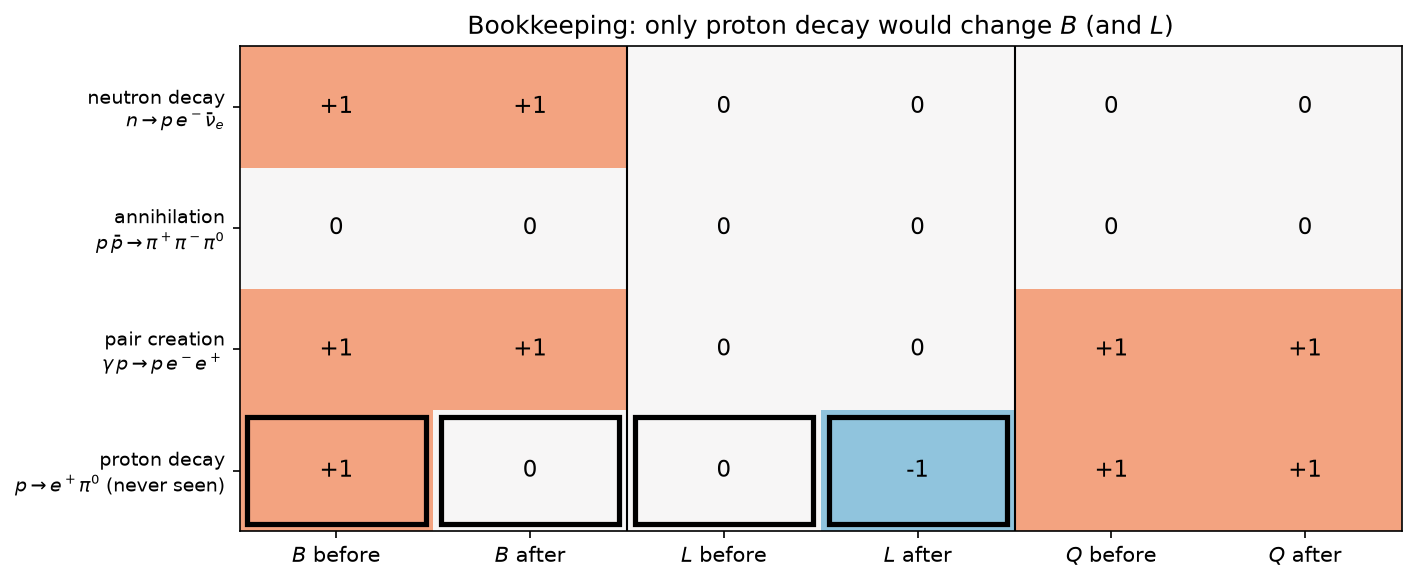

Figure 21d.1 saved as Revision/textbook/figures/21d_1_bookkeeping.png


In [4]:
REACTIONS = ["$n \\to p\\,e^-\\bar\\nu_e$", "$p\\,\\bar p \\to \\pi^+\\pi^-\\pi^0$",
             "$\\gamma\\,p \\to p\\,e^-e^+$", "$p \\to e^+\\pi^0$ (never seen)"]
table = np.array([[float(totals[p[0]][side][k]) for k in range(3)
                   for side in (0, 1)] for p in PROCESSES])  # rows: processes
fig, ax = plt.subplots(figsize=(10.0, 4.2))
ax.imshow(table, cmap="RdBu_r", vmin=-2.5, vmax=2.5, aspect="auto")
for row in range(len(PROCESSES)):
    for col in range(6):
        value = table[row, col]
        ax.text(col, row, "0" if value == 0 else f"{value:+.0f}", ha="center",
                va="center", fontsize=11)
        if col % 2 == 1 and table[row, col] != table[row, col - 1]:  # a change
            for c in (col - 1, col):
                ax.add_patch(plt.Rectangle((c - 0.46, row - 0.44), 0.92, 0.88,
                                           fill=False, linewidth=2.5))
ax.set_xticks(range(6), ["$B$ before", "$B$ after", "$L$ before", "$L$ after",
                         "$Q$ before", "$Q$ after"])
ax.set_yticks(range(len(PROCESSES)), [f"{p[0]}\n{r}" for p, r in
                                      zip(PROCESSES, REACTIONS)], fontsize=9)
for x in (1.5, 3.5):
    ax.axvline(x, color="black", linewidth=1)
ax.grid(False)
ax.set_title("Bookkeeping: only proton decay would change $B$ (and $L$)")
save_figure(fig, "bookkeeping",
            "The totals of the baryon number $B$, the lepton number $L$ and the "
            "electric charge $Q$ before and after four processes (rows): neutron "
            "decay, proton-antiproton annihilation into three pions and pair "
            "creation near a proton (all observed), and proton decay into a "
            "positron and a pion (never observed); columns the number and the side "
            "of the process, colour and figure the total (red positive, blue "
            "negative, pure numbers). Black frames mark the numbers that change: "
            "only proton decay would change $B$ and $L$, the kind of process that "
            "Sakharov's first condition requires.")

## 7. Conditions 1 and 2: a decay model

A heavy toy particle $X$ decays in two ways: with probability $r$ into a channel of
baryon number $B_1$, with probability $1 - r$ into a channel of baryon number
$B_2$. Its antiparticle $\bar X$ decays into the antichannels (baryon numbers
$-B_1$, $-B_2$) with probabilities $\bar r$ and $1 - \bar r$. (Ordinary quantum
field theory makes the *total* decay rates of $X$ and $\bar X$ equal; the
branching probabilities $r$ and $\bar r$ can differ only if C and CP are
violated.) Start with $N$ particles $X$ and $N$ antiparticles $\bar X$; line by
line:

1. One $X$ makes on average $rB_1 + (1 - r)B_2$ baryons.
2. One $\bar X$ makes on average $-\bar rB_1 - (1 - \bar r)B_2$.
3. The total is $N[rB_1 + (1 - r)B_2 - \bar rB_1 - (1 - \bar r)B_2] =
   N[(r - \bar r)B_1 - (r - \bar r)B_2] = N(r - \bar r)(B_1 - B_2)$.

The net baryon number is a **product**: it vanishes if $B_1 = B_2$ (then $X$
carries a conserved baryon number: **condition 1** fails) or if $r = \bar r$
(particle and antiparticle behave alike: **condition 2** fails). The next cell
checks this with sympy and evaluates one example: $X \to qq$ ($B_1 = 2/3$) and
$X \to \bar q\bar\ell$ ($B_2 = -1/3$) with $r = 0.6$, $\bar r = 0.5$.

In [5]:
r, rbar, B1, B2, N = sp.symbols("r rbar B1 B2 N", real=True)
from_X = r * B1 + (1 - r) * B2  # average baryon number made by one X
from_Xbar = -rbar * B1 - (1 - rbar) * B2  # by one antiparticle
net = sp.expand(N * (from_X + from_Xbar))  # N particles and N antiparticles
check(sp.expand(net - N * (r - rbar) * (B1 - B2)) == 0,
      "net baryon number = N (r - rbar) (B1 - B2) exactly")
example = net.subs({N: 1, B1: sp.Rational(2, 3), B2: sp.Rational(-1, 3),
                    r: sp.Rational(3, 5), rbar: sp.Rational(1, 2)})
report("net baryon number per pair X, Xbar for r = 0.6, rbar = 0.5", example)
check(example == sp.Rational(1, 10)
      and net.subs(B2, B1) == 0 and net.subs(rbar, r) == 0,
      "example 1/10 per pair; zero when B1 = B2 or when r = rbar")

PASS net baryon number = N (r - rbar) (B1 - B2) exactly
RESULT net baryon number per pair X, Xbar for r = 0.6, rbar = 0.5 = 1/10
PASS example 1/10 per pair; zero when B1 = B2 or when r = rbar


The next cell draws the net baryon number per pair over all probabilities $r$
and $\bar r$, once for the baryon-number violating particle of the example
($B_1 = 2/3$, $B_2 = -1/3$) and once for a particle whose two channels have the
same baryon number ($B_1 = B_2 = 1/3$).

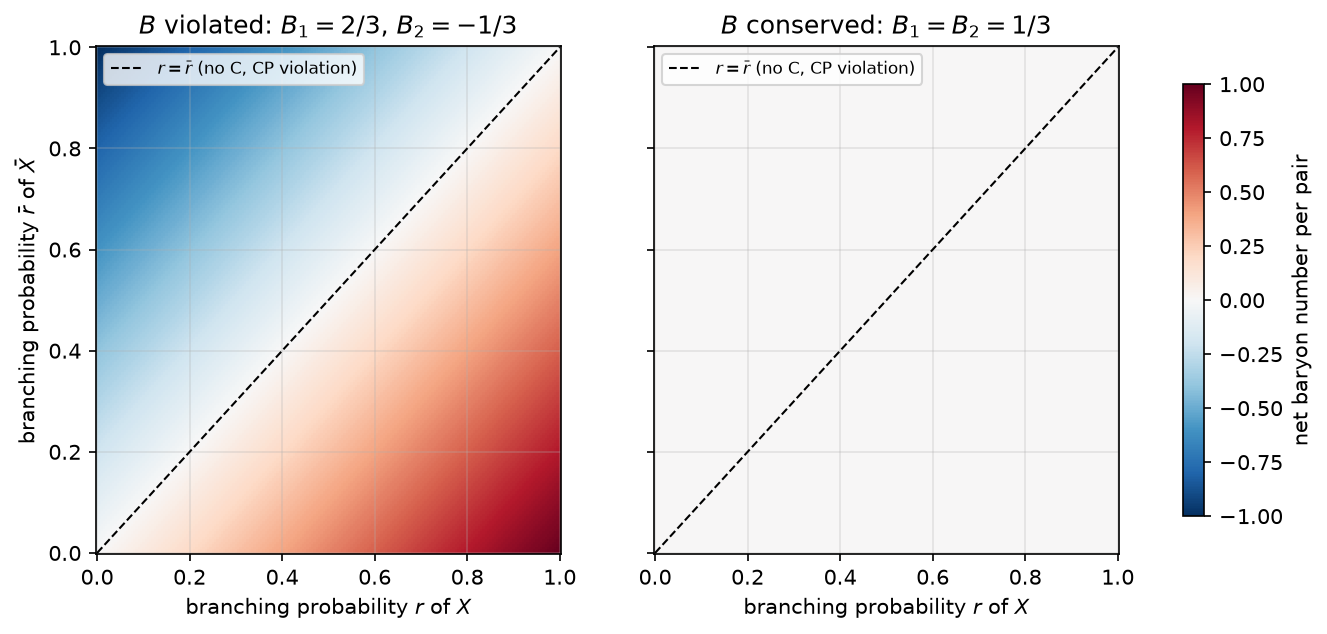

Figure 21d.2 saved as Revision/textbook/figures/21d_2_decay_asymmetry.png


In [6]:
grid = np.linspace(0.0, 1.0, 201)  # values of r and rbar from 0 to 1
R, RBAR = np.meshgrid(grid, grid)
net_f = sp.lambdify((r, rbar, B1, B2), net.subs(N, 1), "numpy")
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4), sharey=True)
for ax, (b1, b2), title in ((axes[0], (2 / 3, -1 / 3), "$B$ violated: $B_1 = 2/3$, "
                             "$B_2 = -1/3$"),
                            (axes[1], (1 / 3, 1 / 3), "$B$ conserved: "
                             "$B_1 = B_2 = 1/3$")):
    values = net_f(R, RBAR, b1, b2) + 0 * R  # + 0 * R: an array even when constant
    image = ax.pcolormesh(R, RBAR, values, cmap="RdBu_r", vmin=-1, vmax=1,
                          shading="auto")
    ax.plot([0, 1], [0, 1], "--", color="black", linewidth=1,
            label="$r = \\bar r$ (no C, CP violation)")
    ax.set_xlabel("branching probability $r$ of $X$")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("branching probability $\\bar r$ of $\\bar X$")
fig.colorbar(image, ax=axes, shrink=0.85, label="net baryon number per pair")
save_figure(fig, "decay_asymmetry",
            "The net baryon number $(r - \\bar r)(B_1 - B_2)$ made by the decays of "
            "one toy particle $X$ and its antiparticle, versus the branching "
            "probability $r$ of $X$ (horizontal) and $\\bar r$ of $\\bar X$ "
            "(vertical), colour the net number (red positive, blue negative). Left: "
            "channels with $B_1 = 2/3$ and $B_2 = -1/3$ (baryon number violated); "
            "the net number vanishes only on the diagonal $r = \\bar r$. Right: "
            "channels with equal baryon number; the net number is zero everywhere. "
            "An asymmetry needs both conditions 1 and 2.")

## 8. Condition 3: equilibrium

In thermal equilibrium at temperature $T$ a state of energy $E$ holds a particle of
baryon number $+1$ with probability $f_+ = 1/(e^{(E - \mu)/T} + 1)$ and the
antiparticle (baryon number $-1$, the same mass, hence the same energy) with
probability $f_- = 1/(e^{(E + \mu)/T} + 1)$; $\mu$ is the chemical potential of
the baryon number. Line by line:

1. $f_+ - f_- = \dfrac{e^{(E + \mu)/T} - e^{(E - \mu)/T}}{(e^{(E - \mu)/T} + 1)
   (e^{(E + \mu)/T} + 1)}$ (common denominator).
2. Multiply out the denominator: $e^{2E/T} + e^{(E - \mu)/T} + e^{(E + \mu)/T} +
   1$; divide numerator and denominator by $e^{E/T}$:
   $f_+ - f_- = \dfrac{2\sinh(\mu/T)}{2\cosh(E/T) + 2\cosh(\mu/T)} =
   \dfrac{\sinh(\mu/T)}{\cosh(E/T) + \cosh(\mu/T)}$.
3. If reactions that change $B$ run back and forth in equilibrium, $B$ is not
   conserved and has no chemical potential: $\mu = 0$, so $\sinh 0 = 0$ and
   $f_+ = f_-$ for **every** energy. No asymmetry.

The next cell checks the formula of line 2 with sympy and evaluates the worked
example $E = 2T$: at $\mu = 0$ both occupations are $1/(e^2 + 1)$; a chemical
potential $\mu = 0.1T$ would give a surplus of particles.

In [7]:
E_T, mu_T = sp.symbols("E_T mu_T", real=True)  # E / T and mu / T
f_plus = 1 / (sp.exp(E_T - mu_T) + 1)
f_minus = 1 / (sp.exp(E_T + mu_T) + 1)
difference = sp.sinh(mu_T) / (sp.cosh(E_T) + sp.cosh(mu_T))
check(sp.simplify((f_plus - f_minus - difference).rewrite(sp.exp)) == 0,
      "f+ - f- = sinh(mu/T) / (cosh(E/T) + cosh(mu/T)) exactly")
at_zero = [float(f.subs({E_T: 2, mu_T: 0})) for f in (f_plus, f_minus)]
at_tenth = [float(f.subs({E_T: 2, mu_T: sp.Rational(1, 10)}))
            for f in (f_plus, f_minus)]
report("f+ = f- at E = 2T, mu = 0", f"{at_zero[0]:.6f}")
report("f+, f- at E = 2T, mu = 0.1 T", f"{at_tenth[0]:.6f}, {at_tenth[1]:.6f}")
report("surplus of particles per state", f"{at_tenth[0] - at_tenth[1]:.6f}")
check(at_zero[0] == at_zero[1] and abs(at_zero[0] - 1 / (np.exp(2) + 1)) < 1e-15
      and at_tenth[0] > at_tenth[1],
      "mu = 0: equal occupations 1/(e^2 + 1); mu > 0: more particles")

PASS f+ - f- = sinh(mu/T) / (cosh(E/T) + cosh(mu/T)) exactly
RESULT f+ = f- at E = 2T, mu = 0 = 0.119203
RESULT f+, f- at E = 2T, mu = 0.1 T = 0.130108, 0.109097
RESULT surplus of particles per state = 0.021012
PASS mu = 0: equal occupations 1/(e^2 + 1); mu > 0: more particles


The next cell draws $f_+ - f_-$ against $E/T$ for four values of $\mu/T$.

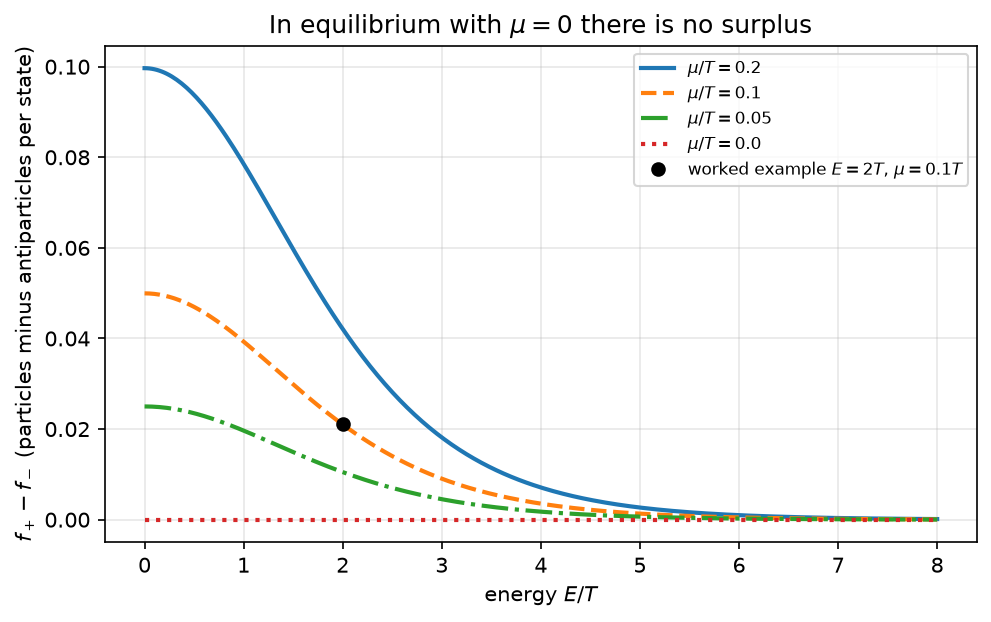

Figure 21d.3 saved as Revision/textbook/figures/21d_3_equilibrium_occupations.png


In [8]:
energies = np.linspace(0.0, 8.0, 321)  # E / T from 0 to 8
diff_f = sp.lambdify((E_T, mu_T), difference, "numpy")
fig, ax = plt.subplots(figsize=(7.5, 4.3))
for mu_value, style in ((0.2, "-"), (0.1, "--"), (0.05, "-."), (0.0, ":")):
    ax.plot(energies, diff_f(energies, mu_value) + 0 * energies, style, linewidth=2,
            label=f"$\\mu/T = {mu_value}$")
ax.plot([2.0], [at_tenth[0] - at_tenth[1]], "o", color="black",
        label="worked example $E = 2T$, $\\mu = 0.1T$")
ax.set_xlabel("energy $E/T$")
ax.set_ylabel("$f_+ - f_-$ (particles minus antiparticles per state)")
ax.set_title("In equilibrium with $\\mu = 0$ there is no surplus")
ax.legend(fontsize=8)
save_figure(fig, "equilibrium_occupations",
            "The surplus $f_+ - f_- = \\sinh(\\mu/T)/(\\cosh(E/T) + \\cosh(\\mu/T))$ "
            "of particles over antiparticles per quantum state in thermal "
            "equilibrium, versus the energy $E/T$ of the state (horizontal) for the "
            "chemical potentials $\\mu/T = 0.2, 0.1, 0.05, 0$ (pure numbers). The "
            "dot is the worked example $E = 2T$, $\\mu = 0.1T$. When the reactions "
            "that change the baryon number are in equilibrium, $\\mu = 0$ and the "
            "surplus vanishes at every energy (dotted line).")

## 9. Condition 3: decays out of equilibrium (a rate model)

A toy universe cools; the time $t$ is measured in units of its cooling time. Let
$n(t)$ be the number of heavy pairs $X$, $\bar X$ (per unit volume, in units of
their starting number) and $n_{eq}(t) = e^{-t}$ the number that equilibrium would
have (heavy particles become rare as the temperature falls). Decays and inverse
decays pull $n$ towards $n_{eq}$ at the rate $K$; each net decay of a pair makes
$\epsilon$ baryons (the number of section 7); inverse decays, which need $X$
particles in equilibrium, erase the asymmetry $a$ at the rate $Kn_{eq}$. The
ASSUMED model is
$$\frac{dn}{dt} = -K(n - n_{eq}),\qquad \frac{da}{dt} = \epsilon K(n - n_{eq})
- Kn_{eq}\,a,\qquad n(0) = 1,\ a(0) = 0 .$$

**Solving it exactly**, line by line.

1. Write $n = n_{eq} + \Delta$. Since $dn_{eq}/dt = -e^{-t}$, the first equation
   becomes $d\Delta/dt = -K\Delta + e^{-t}$ with $\Delta(0) = 0$.
2. Its solution is $\Delta(t) = (e^{-t} - e^{-Kt})/(K - 1)$ (for $K \ne 1$;
   differentiate to check: $(-e^{-t} + Ke^{-Kt})/(K - 1) = -K\Delta + e^{-t}$).
3. With $W(t) = K(1 - e^{-t})$, so $dW/dt = Kn_{eq}$, the second equation is
   $d(a\,e^{W})/dt = \epsilon K\Delta\,e^{W}$ (product rule), hence
   $a(t) = \epsilon\int_0^t K\Delta(s)\,e^{W(s) - W(t)}\,ds$.
4. As $t \to \infty$, $W(t) \to K$ and $W(s) - K = -Ke^{-s}$, so the final
   asymmetry is $a(\infty) = \epsilon\,\eta(K)$ with the **efficiency**
   $\eta(K) = \int_0^\infty K\Delta(s)\,e^{-Ke^{-s}}\,ds$.
5. Substitute $y = e^{-s}$ ($ds = -dy/y$):
   $\eta(K) = \frac{K}{K - 1}\int_0^1(1 - y^{K-1})\,e^{-Ky}\,dy$.
6. $\int_0^1 e^{-Ky}dy = (1 - e^{-K})/K$, and with $u = Ky$,
   $\int_0^1 y^{K-1}e^{-Ky}dy = K^{-K}\gamma(K, K)$, where $\gamma(s, x) =
   \int_0^x u^{s-1}e^{-u}du$ is the *lower incomplete gamma function* (mpmath's
   `gammainc(s, 0, x)`):
   $$\eta(K) = \frac{K}{K - 1}\Big(\frac{1 - e^{-K}}{K} - K^{-K}\gamma(K, K)\Big).$$

The next cell checks lines 1 to 3 with sympy and defines $\eta(K)$ with mpmath
(30 digits).

In [9]:
t, s_, K_s, eps_s = sp.symbols("t s K epsilon", positive=True)
Delta = (sp.exp(-t) - sp.exp(-K_s * t)) / (K_s - 1)  # line 2
W = K_s * (1 - sp.exp(-t))  # line 3
line2_ok = (sp.simplify(sp.diff(Delta, t) - (-K_s * Delta + sp.exp(-t))) == 0
            and Delta.subs(t, 0) == 0)
line3_ok = sp.simplify(sp.diff(W, t) - K_s * sp.exp(-t)) == 0
check(line2_ok and line3_ok, "rate model: Delta(t) and W(t) solve lines 1 to 3")
mpmath.mp.dps = 30  # work with 30 significant digits


def efficiency(K):
    """eta(K) = K/(K - 1) ((1 - e^-K)/K - K^-K gamma(K, K)), K != 1."""
    K = mpmath.mpf(K)
    incomplete = mpmath.gammainc(K, 0, K)  # the lower incomplete gamma(K, K)
    return float(K / (K - 1) * ((1 - mpmath.exp(-K)) / K - K ** (-K) * incomplete))


for K in (0.1, 3.0, 30.0):
    say(f"K = {K:5}: eta = {efficiency(K):.10f}")

PASS rate model: Delta(t) and W(t) solve lines 1 to 3
K =   0.1: eta = 0.9955325865
K =   3.0: eta = 0.4110164748
K =  30.0: eta = 0.0344827586


The next cell integrates the two equations numerically with the classical
fourth-order Runge-Kutta method (RK4) for three rates $K = 0.1$ (slow decays),
$K = 3$ and $K = 30$ (fast decays, close to equilibrium), with $\epsilon = 1$, and
compares $a(\infty)$ with the closed form $\eta(K)$. It also runs two controls: with
$\epsilon = 0$ (no C, CP violation) the asymmetry stays exactly zero, and without
the erasing term the final asymmetry is exactly $\epsilon$ for every $K$ (because
then $da/dt = -\epsilon\,dn/dt$, so $a(\infty) = \epsilon(n(0) - n(\infty)) =
\epsilon$).

In [10]:
def integrate(K, eps=1.0, erase=True, keep_every=50):
    """RK4 for (n, a) from t = 0 to 60 + 40/K; returns the final state and the
    history (every keep_every-th step)."""
    t_end = 60.0 + 40.0 / K  # long enough for n and n_eq to be negligible
    steps = int(np.ceil(t_end / min(0.1 / K, 0.02)))  # step below 0.1/K
    dt = t_end / steps

    def rates(time, y):
        n_eq = np.exp(-time)
        return np.array([-K * (y[0] - n_eq),
                         eps * K * (y[0] - n_eq) - (K * n_eq * y[1] if erase else 0)])

    y, time, history = np.array([1.0, 0.0]), 0.0, [(0.0, 1.0, 0.0)]
    for step in range(steps):
        k1 = rates(time, y)
        k2 = rates(time + dt / 2, y + dt / 2 * k1)
        k3 = rates(time + dt / 2, y + dt / 2 * k2)
        k4 = rates(time + dt, y + dt * k3)
        y = y + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        time += dt
        if (step + 1) % keep_every == 0:
            history.append((time, y[0], y[1]))
    return y, np.array(history)


RATES = (0.1, 3.0, 30.0)
runs = {K: integrate(K) for K in RATES}
for K in RATES:
    say(f"K = {K:5}: RK4 a(infinity) = {runs[K][0][1]:.10f}, "
        f"closed form {efficiency(K):.10f}")
check(all(abs(runs[K][0][1] - efficiency(K)) < 1e-7 for K in RATES),
      "RK4 agrees with the closed form eta(K) to 1e-7 for K = 0.1, 3, 30")
no_cp, _ = integrate(3.0, eps=0.0)
no_erase, _ = integrate(3.0, erase=False)
check(no_cp[1] == 0.0 and abs(no_erase[1] - 1.0) < 1e-9,
      "controls: eps = 0 gives a = 0 exactly; without erasing a(infinity) = eps")

K =   0.1: RK4 a(infinity) = 0.9955325865, closed form 0.9955325865
K =   3.0: RK4 a(infinity) = 0.4110164753, closed form 0.4110164748
K =  30.0: RK4 a(infinity) = 0.0344827586, closed form 0.0344827586
PASS RK4 agrees with the closed form eta(K) to 1e-7 for K = 0.1, 3, 30
PASS controls: eps = 0 gives a = 0 exactly; without erasing a(infinity) = eps


The next cell draws the three histories: the number of heavy pairs $n$, its
equilibrium value $n_{eq}$ and the asymmetry $a/\epsilon$.

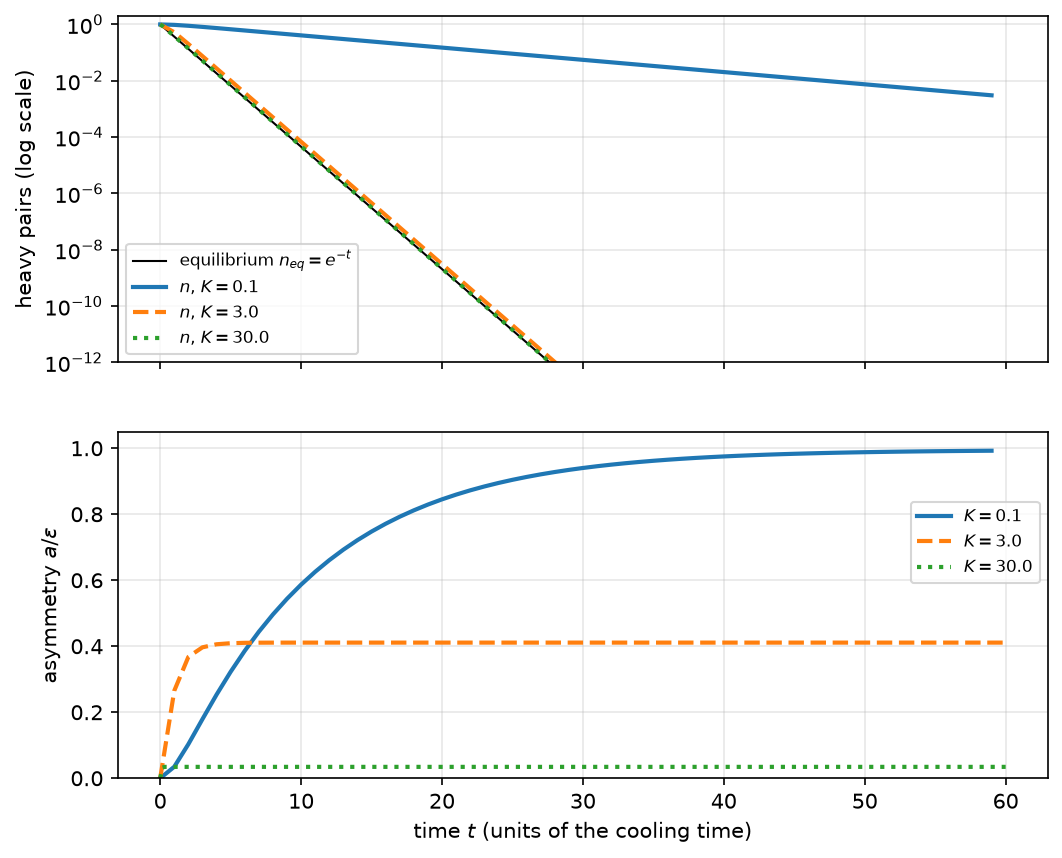

Figure 21d.4 saved as Revision/textbook/figures/21d_4_rate_model_histories.png


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(8.0, 6.6), sharex=True)
times = np.linspace(0.0, 60.0, 601)
axes[0].semilogy(times, np.exp(-times), color="black", linewidth=1,
                 label="equilibrium $n_{eq} = e^{-t}$")
for K, style in zip(RATES, ["-", "--", ":"]):
    history = runs[K][1]
    shown = history[history[:, 0] <= 60.0]
    axes[0].semilogy(shown[:, 0], shown[:, 1], style, linewidth=2,
                     label=f"$n$, $K = {K}$")
    axes[1].plot(shown[:, 0], shown[:, 2], style, linewidth=2, label=f"$K = {K}$")
axes[0].set_ylim(1e-12, 2.0)
axes[0].set_ylabel("heavy pairs (log scale)")
axes[0].legend(fontsize=8, loc="lower left")
axes[1].set_xlabel("time $t$ (units of the cooling time)")
axes[1].set_ylabel("asymmetry $a/\\epsilon$")
axes[1].set_ylim(0.0, 1.05)
axes[1].legend(fontsize=8, loc="center right", bbox_to_anchor=(1.0, 0.68))
save_figure(fig, "rate_model_histories",
            "The rate model of decays out of equilibrium for three decay rates $K$. "
            "Top: the number $n$ of heavy pairs (coloured) and the equilibrium "
            "value $n_{eq} = e^{-t}$ (thin black), logarithmic scale. Bottom: the "
            "asymmetry $a/\\epsilon$. Horizontal axis the time in units of the "
            "cooling time (pure numbers). Slow decays ($K = 0.1$) happen late, "
            "far from equilibrium, when nothing erases their product: almost the "
            "whole $\\epsilon$ survives. Fast decays ($K = 30$) keep $n$ close to "
            "$n_{eq}$, and the inverse decays erase almost everything.")

The next cell computes the efficiency $\eta(K) = a(\infty)/\epsilon$ for 24 rates
from $K = 0.01$ to $K = 1000$ with the closed form and draws it with the three RK4
results. It checks the two limits: $\eta \to 1$ for slow decays, and $\eta =
1/(K - 1)$ up to the exponentially small term $K^{-K}\gamma(K, K)$ for fast ones,
so the asymmetry disappears as the decays approach equilibrium.

PASS efficiency: near 1 for K = 0.01, exactly 1/(K - 1) at K = 1000, decreasing


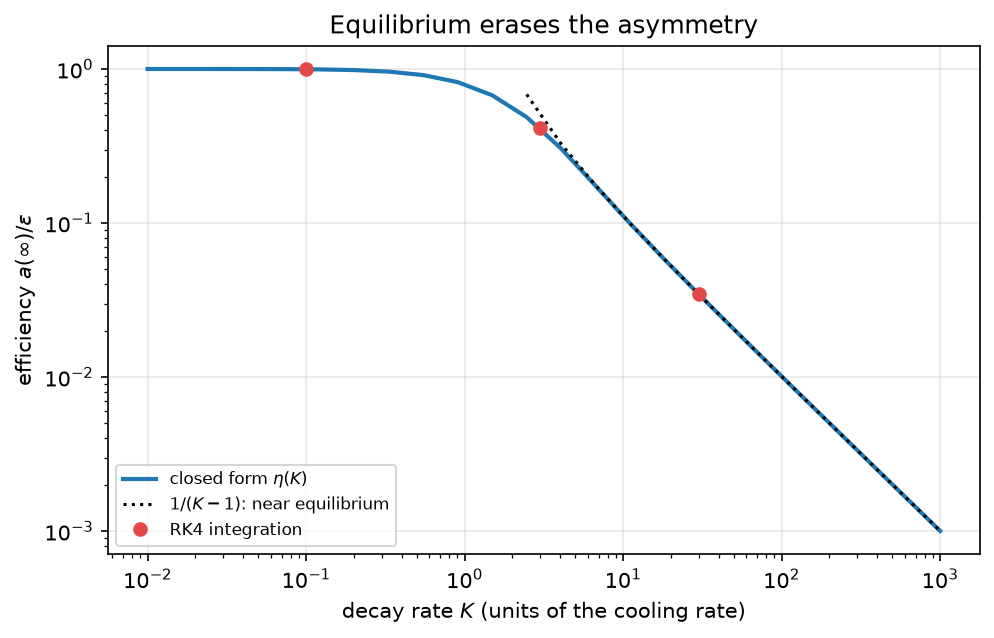

Figure 21d.5 saved as Revision/textbook/figures/21d_5_washout_efficiency.png


In [12]:
K_grid = np.logspace(-2.0, 3.0, 24)  # 24 rates; K = 1 is not among them
eta = np.array([efficiency(K) for K in K_grid])
check(eta[0] > 0.99 and abs(efficiency(1000.0) * 999.0 - 1.0) < 1e-12
      and np.all(np.diff(eta) < 0),
      "efficiency: near 1 for K = 0.01, exactly 1/(K - 1) at K = 1000, decreasing")
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.loglog(K_grid, eta, "-", linewidth=2, label="closed form $\\eta(K)$")
ax.loglog(K_grid[K_grid > 2], 1 / (K_grid[K_grid > 2] - 1), ":", color="black",
          label="$1/(K - 1)$: near equilibrium")
ax.loglog(RATES, [runs[K][0][1] for K in RATES], "o", color="#e34948",
          label="RK4 integration")
ax.set_xlabel("decay rate $K$ (units of the cooling rate)")
ax.set_ylabel("efficiency $a(\\infty)/\\epsilon$")
ax.set_title("Equilibrium erases the asymmetry")
ax.legend(fontsize=8, loc="lower left")
save_figure(fig, "washout_efficiency",
            "The efficiency $\\eta(K) = a(\\infty)/\\epsilon$ of the rate model: the "
            "fraction of the asymmetry made by the decays that survives, versus "
            "the decay rate $K$, both on logarithmic scales (pure numbers). Solid: "
            "the closed form with the incomplete gamma function; dots: the RK4 "
            "integrations; dotted: the limit $1/(K - 1)$. Slow decays (out of "
            "equilibrium) keep almost all of it; the closer the decays are to "
            "equilibrium (large $K$), the less survives: condition 3.")

## 10. This theory, condition 1: the U(1) charge cannot change

The Revision record proves (check u1_noether_matrix_identity) that the U(1) charge
$Q = \int\cos z\,\Psi^\dagger B\Psi\,d^7x$ is exactly conserved on every solution,
in the author's metric with an arbitrary history $a_4(x_4)$, as long as no charge
flows through the boundary. In the language of section 7: every process of this
theory has channels of the **same** charge, $B_1 = B_2$, so the factor
$(B_1 - B_2)$ is zero, and the rate model then starts with $\epsilon = 0$ and ends
with $a = 0$, whatever the rates and however far from equilibrium. The next cell
checks that the record holds this verdict and evaluates the decay formula and the
rate model with this input.

In [13]:
Q_channel = sp.Symbol("Q_channel")  # the common charge of every channel
eps_theory = net.subs({N: 1, B1: Q_channel, B2: Q_channel})  # B1 = B2
a_theory, _ = integrate(0.1, eps=float(eps_theory))  # slow decays, far from equil.
say(f"net charge per pair with equal channels: {eps_theory}; rate model: "
    f"a(infinity) = {a_theory[1]}")
check(LEAD["u1_noether_matrix_identity"] == "PASS" and eps_theory == 0
      and a_theory[1] == 0.0,
      "U(1) charge exactly conserved: no net charge in one universe, condition 1 "
      "fails", record=f"{LEAD_FILE}, check u1_noether_matrix_identity")

net charge per pair with equal channels: 0; rate model: a(infinity) = 0.0
PASS U(1) charge exactly conserved: no net charge in one universe, condition 1 fails
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    u1_noether_matrix_identity


## 11. This theory, condition 2: the conjugations

Condition 2 asks whether particle and antiparticle behave differently. The next
cell evaluates the Lagrangian of the Revision record,
$$\mathcal{L}_{m,\lambda}[\Psi] = \cos z\,\Big[\tfrac12\sum_\mu\big(\bar\Psi
\gamma^\mu D_\mu\Psi - (D_\mu\bar\Psi)\gamma^\mu\Psi\big) - mS -
\tfrac\lambda2S^2\Big],\quad S = \bar\Psi\Psi,\quad \bar\Psi = \Psi^\dagger C,$$
with $D_\mu\Psi = \partial_\mu\Psi + \Omega_\mu\Psi$, $D_\mu\bar\Psi =
\partial_\mu\bar\Psi - \bar\Psi\Omega_\mu$, the record's spin connection
$\Omega_\mu$ (formula Omega_components) and the curved gammas $\gamma^\mu =
\gamma^{(\mu)}/f_\mu$, at one point of the author's metric ($H = 1/6$,
$z = 0.7$, $a_4 = 0.4$, $a_4' = 0.25$), for a fixed commuting field value
$\Psi$ and fixed first derivatives $\partial_\mu\Psi$ (random numbers with a fixed
seed), $m = 0.7$, $\lambda = 0.3$. It compares four numbers:

1. $\mathcal{L}_{m,\lambda}[\Psi]$ and $\mathcal{L}_{m,\lambda}[\Psi^*]$: they are
   **equal**, so the same-mass conjugation $\mathcal{C}_+$ ($\Psi^c = \Psi^*$) is
   an exact symmetry of the commuting field dirac16complex00. (Why: every matrix
   in $\mathcal{L}$, that is $C$, the gammas and $\Omega_\mu$, is real, so
   replacing $\Psi$ by $\Psi^*$ turns $\mathcal{L}$ into its complex conjugate;
   and $\mathcal{L}$ is real.) The map also reverses every current, so it turns
   every solution into a solution of the same theory with the opposite charge. A
   start in which every field configuration and its conjugate are equally likely
   therefore keeps the average charge zero at all times: for the commuting field
   **condition 2 fails** (PROVED).
2. $\mathcal{L}_{m,\lambda}[\Gamma\Psi] = -\mathcal{L}_{-m,-\lambda}[\Psi]$
   (theorem T1, record check T1_Lagrangian_primordial_commuting) and the same for
   $\Gamma\Psi^*$ (the conjugation $\mathcal{C}_-$): these maps reverse the mass.

For the **quantised** field dirac16complex the record proves (check
quantum_charge_conjugation_unitary_type) that the only conjugation compatible with
the canonical anticommutator is $\Psi \to \Gamma\Psi^{\dagger T}$, which reverses
the mass: within one universe of mass $m$ there is no same-mass conjugation of the
quantised field. Whether its particles and antiparticles react at different rates
is NOT COMPUTED: the record computes no reaction rates.

In [14]:
fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
gamma = [np.array(mat, dtype=np.int64) for mat in fixture["gamma"]]  # x1 .. x8
C = gamma[7] @ gamma[0] @ gamma[1] @ gamma[2]  # C = g(x8) g(x1) g(x2) g(x3)
Gamma = C @ gamma[3] @ gamma[4] @ gamma[5] @ gamma[6]  # the chirality
THEORY = {f["key"]: f["wl"] for f in json.loads(repository_file(
    "Revision/theory/field-theory.json").read_text(encoding="utf-8"))["formulas"]}
lagrangian_text = ("L = Cos[z] [ (1/2) sum_mu (Psibar gamma^mu D_mu Psi - (D_mu "
                   "Psibar) gamma^mu Psi) - m S - U(S) ]")
omega_text = ["(1/2) E^a4[x4] Sin[6 H x8]^(1/6) (a4",
              "g[xi].g[x4] + H g[xi].g[x8]) (i = 1, 2, 3)",
              "-(1/2) E^-a4[x4] Sin[6 H x8]^(1/6) (a4",
              "g[x4].g[xt] + H g[xt].g[x8]) (t = 5, 6, 7)", "Omega_x4 = Omega_x8 = 0"]
record_ok = (THEORY["Lagrangian"].startswith(lagrangian_text)
             and all(piece in THEORY["Omega_components"] for piece in omega_text))

H, z, a4, a4p = 1 / 6, 0.7, 0.4, 0.25  # the point of the author's metric
s16 = np.sin(z) ** (1 / 6)
f = [np.exp(a4) * s16] * 3 + [1.0] + [np.exp(-a4) * s16] * 3 + [1 / np.tan(z)]
Omega = []  # the record's formula Omega_components at the point
for mu in range(8):
    if mu < 3:  # x1, x2, x3
        Omega.append(np.exp(a4) * s16 / 2 * (a4p * gamma[mu] @ gamma[3]
                                             + H * gamma[mu] @ gamma[7]))
    elif mu in (4, 5, 6):  # x5, x6, x7: the deflating extra times
        Omega.append(-np.exp(-a4) * s16 / 2 * (a4p * gamma[3] @ gamma[mu]
                                               + H * gamma[mu] @ gamma[7]))
    else:  # x4 and x8
        Omega.append(np.zeros((16, 16)))
gamma_up = [gamma[mu] / f[mu] for mu in range(8)]  # curved gammas at the point


def lagrangian(p, dp, m, lam):
    """The record's Lagrangian at the point for the field value p and the eight
    first derivatives dp[mu] (commuting components)."""
    bar = np.conj(p) @ C  # Psibar = Psi^dagger C
    kinetic = 0.0
    for mu in range(8):
        D = dp[mu] + Omega[mu] @ p  # D_mu Psi
        Dbar = np.conj(dp[mu]) @ C - bar @ Omega[mu]  # D_mu Psibar
        kinetic += (bar @ gamma_up[mu] @ D - Dbar @ gamma_up[mu] @ p) / 2
    S = bar @ p
    return np.cos(z) * (kinetic - m * S - lam / 2 * S ** 2)


rng = np.random.default_rng(2104)  # fixed seed: the same numbers in every run
psi = rng.normal(size=16) + 1j * rng.normal(size=16)
dpsi = rng.normal(size=(8, 16)) + 1j * rng.normal(size=(8, 16))
m_value, lam_value = 0.7, 0.3
values = {
    "L[Psi]": lagrangian(psi, dpsi, m_value, lam_value),
    "L[Psi*]": lagrangian(np.conj(psi), np.conj(dpsi), m_value, lam_value),
    "L[Gamma Psi]": lagrangian(Gamma @ psi, dpsi @ Gamma.T, m_value, lam_value),
    "L[Gamma Psi*]": lagrangian(Gamma @ np.conj(psi), np.conj(dpsi) @ Gamma.T,
                                m_value, lam_value),
    "-L_(-m,-lambda)[Psi]": -lagrangian(psi, dpsi, -m_value, -lam_value)}
for label, value in values.items():
    say(f"{label:21}: {value.real:+.10f} (imaginary part below 1e-12: "
        f"{abs(value.imag) < 1e-12})")
check(record_ok and all(abs(v.imag) < 1e-12 for v in values.values())
      and abs(values["L[Psi*]"] - values["L[Psi]"]) < 1e-12,
      "commuting field: L[Psi*] = L[Psi], the same-mass conjugation is exact")
check(abs(values["L[Gamma Psi]"] - values["-L_(-m,-lambda)[Psi]"]) < 1e-12
      and abs(values["L[Gamma Psi*]"] - values["-L_(-m,-lambda)[Psi]"]) < 1e-12
      and PAIR["T1_Lagrangian_primordial_commuting"] == "PASS",
      "L[Gamma Psi] = L[Gamma Psi*] = -L_(-m,-lambda)[Psi]: these maps reverse m",
      record=f"{PAIR_FILE}, check T1_Lagrangian_primordial_commuting")
check(LEAD["bilinears_under_charge_conjugation"] == "PASS"
      and LEAD["quantum_charge_conjugation_unitary_type"] == "PASS",
      "record: calC_+ keeps S and reverses J (commuting); the quantised field has "
      "only the mass-reversing conjugation",
      record=f"{LEAD_FILE}, check quantum_charge_conjugation_unitary_type")

L[Psi]               : -11.2851368126 (imaginary part below 1e-12: True)
L[Psi*]              : -11.2851368126 (imaginary part below 1e-12: True)
L[Gamma Psi]         : +8.4767165144 (imaginary part below 1e-12: True)
L[Gamma Psi*]        : +8.4767165144 (imaginary part below 1e-12: True)
-L_(-m,-lambda)[Psi] : +8.4767165144 (imaginary part below 1e-12: True)
PASS commuting field: L[Psi*] = L[Psi], the same-mass conjugation is exact
PASS L[Gamma Psi] = L[Gamma Psi*] = -L_(-m,-lambda)[Psi]: these maps reverse m
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    T1_Lagrangian_primordial_commuting
PASS record: calC_+ keeps S and reverses J (commuting); the quantised field has only the
    mass-reversing conjugation
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    quantum_charge_conjugation_unitary_type


The next cell draws the five numbers of the previous cell.

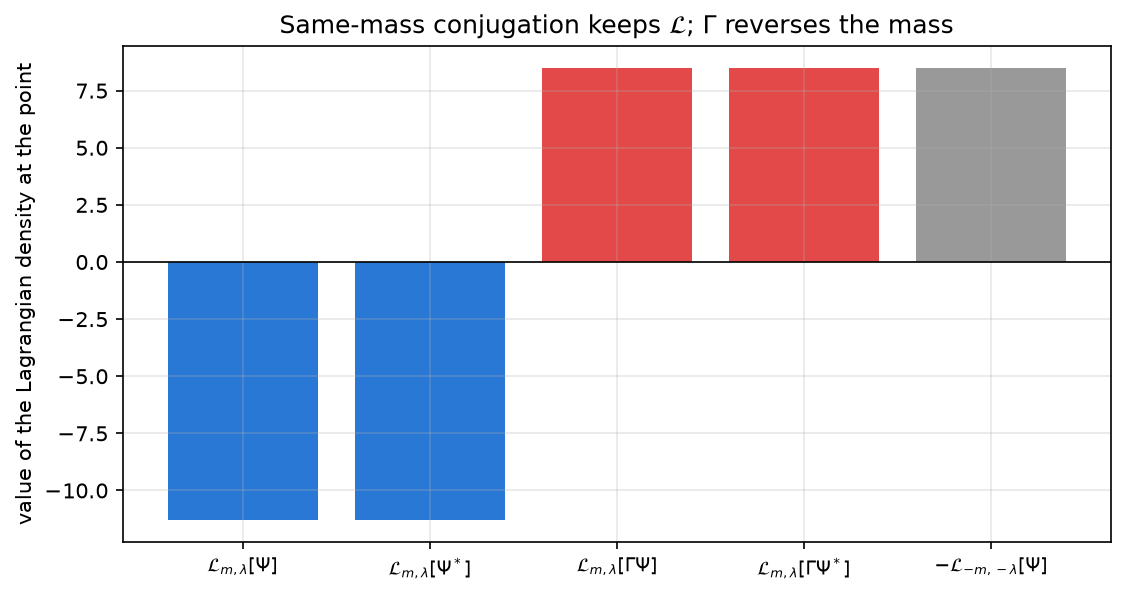

Figure 21d.6 saved as Revision/textbook/figures/21d_6_lagrangian_maps.png


In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4.3))
labels = ["$\\mathcal{L}_{m,\\lambda}[\\Psi]$", "$\\mathcal{L}_{m,\\lambda}[\\Psi^*]$",
          "$\\mathcal{L}_{m,\\lambda}[\\Gamma\\Psi]$",
          "$\\mathcal{L}_{m,\\lambda}[\\Gamma\\Psi^*]$",
          "$-\\mathcal{L}_{-m,-\\lambda}[\\Psi]$"]
colours = ["#2a78d6", "#2a78d6", "#e34948", "#e34948", "#999999"]
ax.bar(range(5), [v.real for v in values.values()], color=colours)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(range(5), labels, fontsize=9)
ax.set_ylabel("value of the Lagrangian density at the point")
ax.set_title("Same-mass conjugation keeps $\\mathcal{L}$; $\\Gamma$ reverses the mass")
save_figure(fig, "lagrangian_maps",
            "The Lagrangian density of the Revision record for the commuting field "
            "at one point of the author's metric ($H = 1/6$, $z = 0.7$, $a_4 = 0.4$, "
            "$a_4' = 0.25$, $m = 0.7$, $\\lambda = 0.3$, a fixed field value and "
            "fixed first derivatives): for $\\Psi$ and its same-mass conjugate "
            "$\\Psi^\\ast$ (blue, equal), for the images $\\Gamma\\Psi$ and "
            "$\\Gamma\\Psi^\\ast$ (red) and for minus the Lagrangian of the reversed "
            "mass and coupling (grey); vertical axis the value (pure numbers). The "
            "red bars equal the grey one: $\\Gamma$ maps the theory with $(m, "
            "\\lambda)$ to the theory with $(-m, -\\lambda)$.")

## 12. What a charge-violating term would look like

Condition 1 could be met only by adding to the theory a term that is not
invariant under $\Psi \to e^{i\alpha}\Psi$. The simplest candidates are
**Majorana-type mass terms** $\Psi^TM\Psi$ with a constant $16 \times 16$ matrix
$M$. Such a term must still be invariant under the rotations and boosts of
Spin(4,4), $\Psi \to R\Psi$ with $R = e^{\theta S^{ab}}$, that is $R^TMR = M$; for
small $\theta$ this is
$$(S^{ab})^TM + MS^{ab} = 0\quad\text{for all 28 generators } S^{ab} .$$
The next cell solves these $28 \cdot 256 = 7168$ linear equations exactly (as in
the search for the charge-conjugation matrices) and finds a two-dimensional space
spanned by $C$ and $C\Gamma$. (This reproduces the Revision algebra check
spin_commutant_dimension_2: $M$ solves the equations exactly when $CM$ commutes
with every $S^{ab}$, because $CS^{ab}C = -(S^{ab})^T$.) It also checks a finite
transformation $R$ (a product of three rotations and boosts, built from
$e^{\theta S} = \cos(\theta/2) + 2\sin(\theta/2)S$ when $S^2 = -\tfrac14$ and
$\cosh(\theta/2) + 2\sinh(\theta/2)S$ when $S^2 = +\tfrac14$).

**For anticommuting components these terms vanish.** With $\Psi_r\Psi_c =
-\Psi_c\Psi_r$ and $\Psi_r\Psi_r = 0$, $\Psi^TM\Psi = \sum_{r<c}(M_{rc} -
M_{cr})\Psi_r\Psi_c$ keeps only the antisymmetric part of $M$; $C$ and $C\Gamma$
are symmetric, so the field dirac16complex has **no** Majorana-type mass term. For
the commuting field dirac16complex00 they survive and carry charge 2.

In [16]:
from sympy.polys.matrices import DomainMatrix  # exact matrices over the rationals

I16 = np.eye(16, dtype=np.int64)
pairs = [(a, b) for a in range(8) for b in range(a + 1, 8)]  # the 28 generators
S2 = {(a, b): gamma[a] @ gamma[b] for a, b in pairs}  # 2 S^ab = gamma^a gamma^b
# unknown M read row by row: S^T M -> kron(S^T, 1), M S -> kron(1, S^T)
system = np.vstack([np.kron(S.T, I16) + np.kron(I16, S.T) for S in S2.values()])
null = DomainMatrix.from_list(system.tolist(), sp.QQ).nullspace().to_Matrix()
basis = np.array([np.array(null.row(k).tolist()[0], dtype=float)
                  for k in range(null.rows)])  # each row: one solution, 256 numbers
CG = C @ Gamma
span_ok = all(np.linalg.matrix_rank(np.vstack([basis, M.reshape(1, -1)])) == 2
              for M in (C, CG))
say(f"{system.shape[0]} equations; dimension of the solution space: {null.rows}")
check(null.rows == 2 and span_ok
      and all(np.array_equal(C @ S @ C, -S.T) for S in S2.values())
      and ALGEBRA["spin_commutant_dimension_2"] == "PASS",
      "invariant Majorana-type matrices: a 2-dimensional space spanned by C, C Gamma",
      record=f"{ALGEBRA_FILE}, check spin_commutant_dimension_2")

ETA = [1, 1, 1, -1, -1, -1, -1, 1]


def exp_generator(a, b, theta):
    """exp(theta S^ab) for S^ab = gamma^a gamma^b / 2 (a rotation or a boost)."""
    S = S2[(a, b)] / 2
    if ETA[a] * ETA[b] == 1:  # S^2 = -1/4: a rotation
        return np.cos(theta / 2) * np.eye(16) + 2 * np.sin(theta / 2) * S
    return np.cosh(theta / 2) * np.eye(16) + 2 * np.sinh(theta / 2) * S  # a boost


R = exp_generator(0, 1, 0.7) @ exp_generator(0, 3, 0.4) @ exp_generator(4, 7, -1.1)
check(np.allclose(R.T @ C @ R, C) and np.allclose(R.T @ CG @ R, CG)
      and not np.allclose(R.T @ R, np.eye(16)),
      "a finite rotation-boost R keeps C and C Gamma (R^T M R = M), not the identity")
symmetric = np.array_equal(C, C.T) and np.array_equal(CG, CG.T)
psi_c = rng.normal(size=16) + 1j * rng.normal(size=16)  # a commuting field value
alpha = 0.9
phase_ok = all(np.isclose((np.exp(1j * alpha) * psi_c) @ M @ (np.exp(1j * alpha)
                                                              * psi_c),
                          np.exp(2j * alpha) * (psi_c @ M @ psi_c)) for M in (C, CG))
check(symmetric and phase_ok and abs(psi_c @ C @ psi_c) > 0.1,
      "C, C Gamma symmetric: zero for anticommuting components; for commuting "
      "ones nonzero, charge 2")

7168 equations; dimension of the solution space: 2
PASS invariant Majorana-type matrices: a 2-dimensional space spanned by C, C Gamma
     reproduces Revision/algebra/reports/python-algebra.json, check
    spin_commutant_dimension_2
PASS a finite rotation-boost R keeps C and C Gamma (R^T M R = M), not the identity
PASS C, C Gamma symmetric: zero for anticommuting components; for commuting ones nonzero,
    charge 2


The next cell draws the two invariant matrices and the phase that the
Majorana-type term $\Psi^TC\Psi$ and the U(1)-invariant scalar $S = \Psi^\dagger
C\Psi$ acquire under $\Psi \to e^{i\alpha}\Psi$.

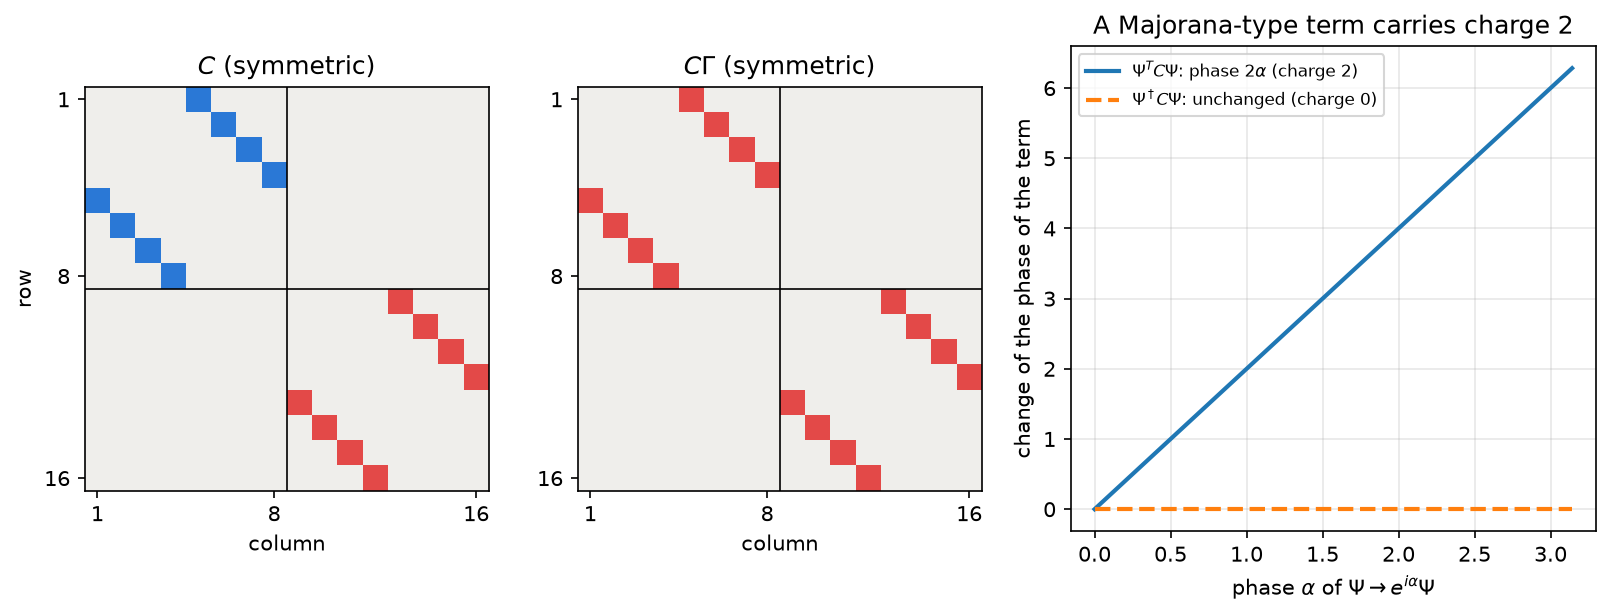

Figure 21d.7 saved as Revision/textbook/figures/21d_7_majorana_terms.png


In [17]:
from matplotlib.colors import LinearSegmentedColormap

SIGNS = LinearSegmentedColormap.from_list("signs", ["#2a78d6", "#f0efec", "#e34948"])
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.2), width_ratios=[1, 1, 1.3])
for ax, M, title in ((axes[0], C, "$C$ (symmetric)"),
                     (axes[1], CG, "$C\\Gamma$ (symmetric)")):
    image = ax.imshow(M, cmap=SIGNS, vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xticks([0, 7, 15], ["1", "8", "16"])
    ax.set_yticks([0, 7, 15], ["1", "8", "16"])
    ax.set_xlabel("column")
    ax.axhline(7.5, color="black", linewidth=0.8)
    ax.axvline(7.5, color="black", linewidth=0.8)
    ax.grid(False)
axes[0].set_ylabel("row")
alphas = np.linspace(0.0, np.pi, 91)
majorana = np.array([(np.exp(1j * x) * psi_c) @ C @ (np.exp(1j * x) * psi_c)
                     for x in alphas])
scalar = np.array([np.conj(np.exp(1j * x) * psi_c) @ C @ (np.exp(1j * x) * psi_c)
                   for x in alphas])
base = np.angle(majorana[0])
axes[2].plot(alphas, np.unwrap(np.angle(majorana)) - base, linewidth=2,
             label="$\\Psi^T C\\Psi$: phase $2\\alpha$ (charge 2)")
axes[2].plot(alphas, np.angle(scalar) - np.angle(scalar[0]), "--", linewidth=2,
             label="$\\Psi^\\dagger C\\Psi$: unchanged (charge 0)")
axes[2].set_xlabel("phase $\\alpha$ of $\\Psi \\to e^{i\\alpha}\\Psi$")
axes[2].set_ylabel("change of the phase of the term")
axes[2].legend(fontsize=8)
axes[2].set_title("A Majorana-type term carries charge 2")
save_figure(fig, "majorana_terms",
            "Left and middle: heat maps of the only two matrices $M$ for which a "
            "Majorana-type term $\\Psi^T M\\Psi$ is invariant under the rotations and "
            "boosts of Spin(4,4), $C$ and $C\\Gamma$ (horizontal axis the column, "
            "vertical axis the row, red $+1$, blue $-1$); both are symmetric, so "
            "the term vanishes for anticommuting components. Right: the change of "
            "the phase of $\\Psi^T C\\Psi$ (solid) and of $\\Psi^\\dagger C\\Psi$ "
            "(dashed) for a commuting field under $\\Psi \\to e^{i\\alpha}\\Psi$, "
            "versus $\\alpha$ (radians): the Majorana-type term turns twice as "
            "fast, it carries U(1) charge 2 and would break the charge "
            "conservation.")

## 13. The scorecard

The next cell builds the scorecard of this theory from the verdicts of the
Revision record (each status is set only if the record holds the named check
with the verdict PASS) and draws it as a table. Condition 2 has two statuses: it
fails for the commuting field (its same-mass conjugation is exact, section 11;
the record checks that the gammas, $C$ and $\Omega_\mu$ are real and that the
conjugation reverses the current), and it is not computed for the quantised field
(no rates; its only conjugation reverses the mass). Condition 3: the Revision
record contains no computation of reaction rates or of a departure from
equilibrium; its Kohn-Sham history is a prescribed background (record check
ks_history_is_a_prescribed_background), not a dynamical history.

In [18]:
def status(passed, text):
    """The status text when the record check passed, otherwise UNSUPPORTED."""
    return text if passed else "UNSUPPORTED"


ROWS = [
    ("1. a process changes the number",
     "U(1) charge Q exactly conserved for every history a4 (no flux through the "
     "boundary)",
     status(LEAD["u1_noether_matrix_identity"] == "PASS", "FAILS (PROVED)"),
     "u1_noether_matrix_identity"),
    ("2. C and CP violated",
     "commuting field: the same-mass conjugation is an exact symmetry that "
     "reverses the charge, so a C-symmetric start keeps zero charge; quantised "
     "field: the only conjugation, Gamma, reverses the mass; no rates computed",
     status(all(LEAD[name] == "PASS" for name in (
         "representation_real", "spinor_connection_real",
         "bilinears_under_charge_conjugation",
         "quantum_charge_conjugation_unitary_type")),
         "commuting: FAILS (PROVED); quantised: NOT COMPUTED"),
     "representation_real, spinor_connection_real, "
     "bilinears_under_charge_conjugation, quantum_charge_conjugation_unitary_type"),
    ("3. out of equilibrium",
     "no rate computed; the Kohn-Sham history is a prescribed background",
     status(KS["ks_history_is_a_prescribed_background"] == "PASS", "NOT COMPUTED"),
     "ks_history_is_a_prescribed_background"),
    ("pair level (theorem T1)",
     "the partner Gamma Psi of mass -m carries the opposite current: total charge 0",
     status(PAIR["T1_current_primordial_commuting"] == "PASS"
            and PAIR["T1_current_primordial_grassmann"] == "PASS",
            "PROVED (classical bilinears)"),
     "T1_current_primordial_commuting, T1_current_primordial_grassmann"),
    ("verdict",
     "no net charge can be made inside one universe; no baryons in the theory",
     status(LEAD["u1_noether_matrix_identity"] == "PASS", "PROBLEM NOT SOLVED"),
     "the checks above")]
for row in ROWS:
    say(f"{row[0]:34} | {row[2]}")
check([row[2] for row in ROWS] == ["FAILS (PROVED)",
                                   "commuting: FAILS (PROVED); quantised: NOT COMPUTED",
                                   "NOT COMPUTED", "PROVED (classical bilinears)",
                                   "PROBLEM NOT SOLVED"],
      "scorecard: every status is backed by a PASS verdict of the Revision record")

1. a process changes the number    | FAILS (PROVED)
2. C and CP violated               | commuting: FAILS (PROVED); quantised: NOT COMPUTED
3. out of equilibrium              | NOT COMPUTED
pair level (theorem T1)            | PROVED (classical bilinears)
verdict                            | PROBLEM NOT SOLVED
PASS scorecard: every status is backed by a PASS verdict of the Revision record


The next cell draws the scorecard.

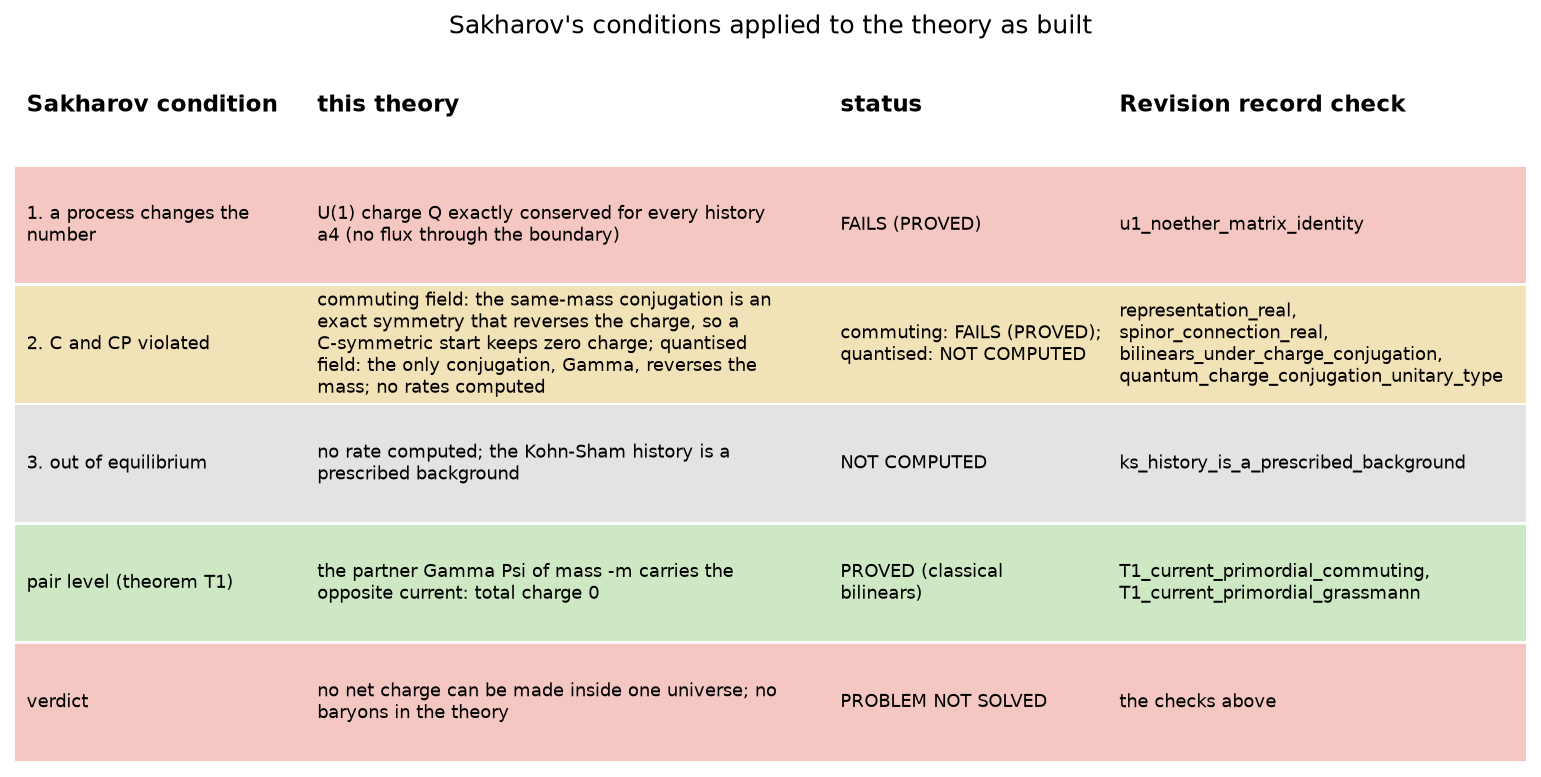

Figure 21d.8 saved as Revision/textbook/figures/21d_8_scorecard.png


In [19]:
COLOURS = {"FAILS (PROVED)": "#f4c7c3",
           "commuting: FAILS (PROVED); quantised: NOT COMPUTED": "#f2e2b8",
           "NOT COMPUTED": "#e3e3e3", "PROVED (classical bilinears)": "#cfe8c4",
           "PROBLEM NOT SOLVED": "#f4c7c3"}
fig, ax = plt.subplots(figsize=(13.0, 6.2))
ax.set_xlim(0, 13.0)
ax.set_ylim(0, len(ROWS) + 1)
ax.axis("off")
columns = [(0.1, 2.4, "Sakharov condition"), (2.6, 4.3, "this theory"),
           (7.1, 2.3, "status"), (9.5, 3.5, "Revision record check")]
for x0, width, heading in columns:
    ax.text(x0, len(ROWS) + 0.5, heading, fontsize=11, fontweight="bold",
            va="center")
for k, row in enumerate(ROWS):
    y = len(ROWS) - k - 0.5  # the first row at the top
    ax.add_patch(plt.Rectangle((0.0, y - 0.48), 13.0, 0.96, color=COLOURS[row[2]],
                               zorder=0))
    for (x0, width, _), text in zip(columns, row):
        chars = int(width * 11.5)  # about 11 characters per unit of width
        ax.text(x0, y, textwrap.fill(text, chars, break_long_words=False),
                fontsize=8.5, va="center")  # long check names stay whole
ax.set_title("Sakharov's conditions applied to the theory as built", fontsize=12)
save_figure(fig, "scorecard",
            "The scorecard of the theory as built against Sakharov's three "
            "conditions, with the status of each row and the Revision record "
            "check it rests on (each status is set by the notebook only when the "
            "record holds that check with the verdict PASS). Condition 1 fails "
            "exactly (the U(1) charge is conserved for every history $a_4$), so "
            "conditions 2 and 3 cannot help; condition 2 also fails for the "
            "commuting field (its same-mass conjugation is exact) and is not "
            "computed for the quantised field; the pair-level statement of theorem "
            "T1 is exact but creates nothing. The theory does not solve the "
            "matter-antimatter problem.")

## 14. The figure files

The last cell checks that the eight figure files exist and prints the number of
checks that passed.

In [20]:
names = sorted(FIGURE_NUMBERS, key=FIGURE_NUMBERS.get)
check(len(names) == 8 and all(
    output_file(f"{FIGURE_FOLDER}/21d_{FIGURE_NUMBERS[n]}_{n}.png").is_file()
    for n in names), "the eight figure files of notebook 21d exist")
all_checks_passed()

PASS the eight figure files of notebook 21d exist
ALL 19 CHECKS PASSED (notebook 21d)


## 15. What this notebook showed

- ASSUMED (known physics, quoted): Sakharov's three conditions; the quark content
  and the numbers $B$, $L$, $Q$ of the particles.
- COMPUTED (exact fractions): the three observed processes conserve $B$, $L$ and
  $Q$; proton decay $p \to e^+\pi^0$ would change $B$ and $L$ by $-1$ each and
  keep $B - L$.
- PROVED (sympy) for the toy decay model: the net baryon number is $N(r - \bar r)
  (B_1 - B_2)$, zero unless both condition 1 and condition 2 hold; example $1/10$
  per pair.
- PROVED: in equilibrium $f_+ - f_- = \sinh(\mu/T)/(\cosh(E/T) + \cosh(\mu/T))$,
  zero for $\mu = 0$.
- PROVED (closed form, checked by RK4 to $10^{-7}$) for the ASSUMED rate model:
  the surviving fraction of the asymmetry is $\eta(K)$, near 1 for slow decays and
  $1/(K - 1)$ for fast ones: condition 3.
- This theory (Revision record): the U(1) charge is exactly conserved
  (u1_noether_matrix_identity), so no process of the theory can make a net charge
  inside one universe, whatever the rates and however far from equilibrium:
  condition 1 FAILS. The same-mass conjugation is an exact symmetry of the
  commuting field (COMPUTED here at a point of the author's metric) that reverses
  the charge, so condition 2 FAILS for the commuting field (PROVED); the quantised
  field has only the mass-reversing conjugation (quantum_charge_conjugation_
  unitary_type), and C and CP violation in its rates is NOT COMPUTED; no departure
  from equilibrium is computed (the Kohn-Sham history is a prescribed background).
- PROVED (exact linear algebra): the only Spin(4,4)-invariant Majorana-type mass
  matrices are $C$ and $C\Gamma$; both are symmetric, so the anticommuting field
  has no such term; for the commuting field they carry U(1) charge 2.
- The pair-level statement (theorem T1, PROVED for classical bilinears): the
  partner of mass $-m$ carries the opposite current, so a pair has total charge
  zero. That pairs of universes exist, or were created, is a HYPOTHESIS (the
  universe/anti-universe class of ideas; a published example is L. Boyle, K. Finn
  and N. Turok, Phys. Rev. Lett. 121, 251301 (2018)); this theory does not derive
  it.
- **The theory as built does not solve the matter-antimatter problem.** What would
  be needed (OPEN): baryons in the theory; a charge-violating interaction (for the
  commuting field a Majorana-type term like the ones found here; the
  anticommuting field has no invariant mass-type term, so it would need terms
  with derivatives, more fields or new background structures, which are not
  classified here); CP violation in reaction rates; and a computed departure from
  equilibrium along a dynamical history of the deflating extra times.